In [25]:
### TASK 1 — Data Loading & Exploration ###
import pandas as pd
df = pd.read_csv(r"C:\Users\ravis\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv") #Loading the csv file using the pandas
print("First 10 Rows:")   #Display of First 10 rows
df.head(10)

First 10 Rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [26]:
print("Dataset Shape:", df.shape)
rows, columns = df.shape # number of rows and columns
print("Rows:", rows)
print("Columns:", columns)

Dataset Shape: (1470, 35)
Rows: 1470
Columns: 35


In [27]:
target_column = "Attrition" # identifying the target variable
print(f"\nTarget Column: {target_column}")


Target Column: Attrition


In [28]:
attrition_counts = df["Attrition"].value_counts() # count employess who left vs stayed
print(attrition_counts)
attrition_rate = (attrition_counts["Yes"] / len(df)) * 100 # calculate attrition rate
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [29]:
numeric_columns = df.select_dtypes(include=["number"]).columns  #Numeric columns
categorical_columns = df.select_dtypes(exclude=["number"]).columns  # Categorical columns
print("Number of Numeric Columns:", len(numeric_columns))
print("Number of Categorical Columns:", len(categorical_columns))
print("\nNumeric Columns:")
print(list(numeric_columns))
print("\nCategorical Columns:")
print(list(categorical_columns))

Number of Numeric Columns: 26
Number of Categorical Columns: 9

Numeric Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [30]:
print("""
Observation

-> The company has 1,470 employees, and 237 employees left the organization, resulting in an attrition rate of 16.12%.
-> This means that roughly 1 out of every 6 employees left the company during the period covered by the data.
-> The dataset is imbalanced, because most employees stayed are 1,233 employees while a much smaller group left of 237 employees. 
   This is important because employee departures are relatively uncommon compared to employees who remain with the company.
   """)


Observation

-> The company has 1,470 employees, and 237 employees left the organization, resulting in an attrition rate of 16.12%.
-> This means that roughly 1 out of every 6 employees left the company during the period covered by the data.
-> The dataset is imbalanced, because most employees stayed are 1,233 employees while a much smaller group left of 237 employees. 
   This is important because employee departures are relatively uncommon compared to employees who remain with the company.
   


In [31]:
### Task 2 — Data Cleaning & Preprocessing ###

from sklearn.preprocessing import StandardScaler
print(df.isnull().sum()) # Checking missing values

for col in df.select_dtypes(include=['int64', 'float64']).columns: # Filling missing values
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.drop(columns=['EmployeeNumber', 'Over18', 'StandardHours'], inplace=True)  # Droping unnecessary columns


df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})  # Convert the target column Attrition from Yes/No to 1/0

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X = pd.get_dummies(X, drop_first=True)  # # Using one-Hot Encoding
print("Shape after encoding:", X.shape)

scaler = StandardScaler()  # feature Scaling
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
print("Scaled data shape:", X_scaled.shape)
display(X_scaled.head(10))



Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,1.153254,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,0.246200,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,0.246200,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
5,-0.539166,0.502054,-0.887515,-0.891688,0.0,1.169781,0.645041,0.379672,-0.961486,1.153254,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.628241
6,2.417384,1.292887,-0.764121,0.085049,0.0,0.254625,0.743454,1.785511,-0.961486,-1.567907,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,1.591746
7,-0.758170,1.377177,1.827158,-1.868426,0.0,1.169781,0.054562,0.379672,-0.961486,0.246200,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,-0.685565,-0.628241
8,0.117845,-1.453958,1.703764,0.085049,0.0,1.169781,-1.077188,-1.026167,0.845911,0.246200,...,-0.462464,-0.273059,3.022901,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,-0.628241
9,-0.101159,1.230910,2.197341,0.085049,0.0,0.254625,1.383138,0.379672,-0.057788,0.246200,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


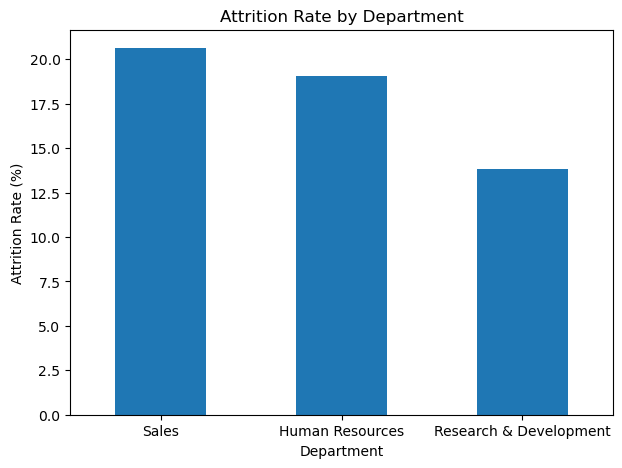

In [32]:
### Task 3 — Exploratory Data Analysis — EDA ###

# 1.Attrition Rate by Department #

import pandas as pd
import matplotlib.pyplot as plt

department_attrition = (df.groupby("Department")["Attrition"].mean().sort_values(ascending=False) * 100)
print(department_attrition)

plt.figure(figsize=(7,5))
department_attrition.plot(kind='bar')
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


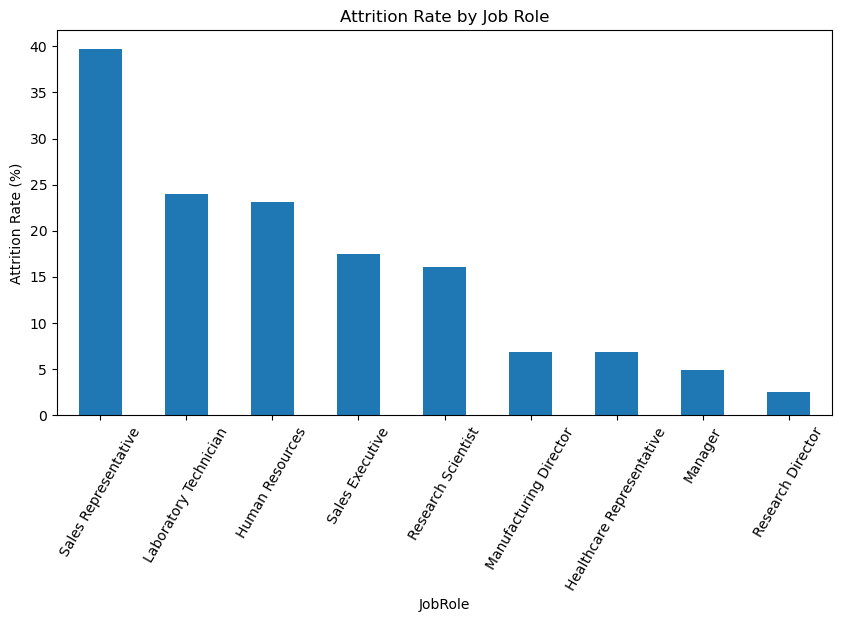

In [33]:
# 2.Attrition Rate by Job Role #

jobrole_attrition = (df.groupby("JobRole")["Attrition"].mean().sort_values(ascending=False) * 100)
print(jobrole_attrition)

plt.figure(figsize=(10,5))
jobrole_attrition.plot(kind='bar')
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=60)
plt.show()

,Attrition,Median Monthly Income
0,Stayed,5204.0
1,Left,3202.0


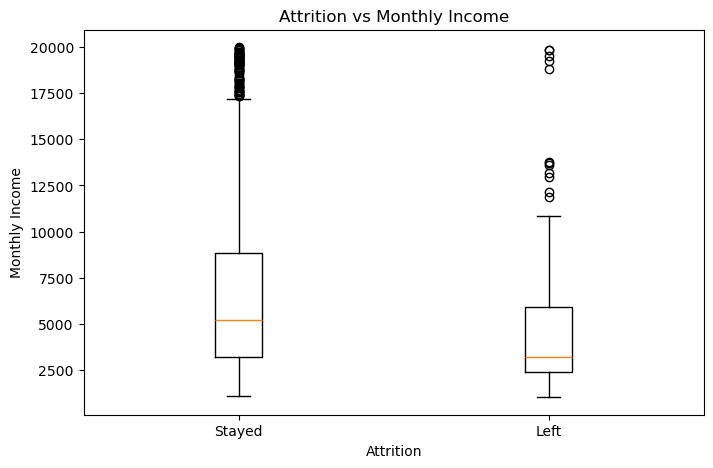

In [34]:
# 3. Attrition vs Monthly Income #

income_summary = (df.groupby("Attrition")["MonthlyIncome"].median().reset_index())
income_summary["Attrition"] = income_summary["Attrition"].map({0: "Stayed", 1: "Left"})
income_summary.rename(columns={"MonthlyIncome": "Median Monthly Income"}, inplace=True)
display(income_summary)

plt.figure(figsize=(8,5))
plt.boxplot([df[df["Attrition"] == 0]["MonthlyIncome"],df[df["Attrition"] == 1]["MonthlyIncome"]],tick_labels=["Stayed", "Left"])
plt.title("Attrition vs Monthly Income")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


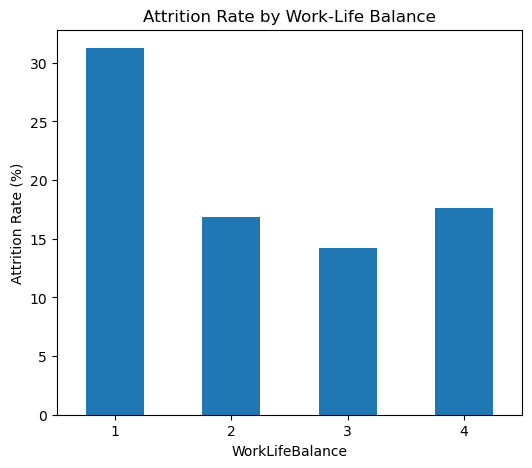

In [102]:
#4. Attrition vs Work-Life Balance #

workLifeBalance_attrition = (df.groupby("WorkLifeBalance")["Attrition"].mean() * 100)
print(workLifeBalance_attrition)

plt.figure(figsize=(6,5))
wlb_attrition.plot(kind='bar')
plt.title("Attrition Rate by Work-Life Balance")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

YearsAtCompany
0     36.363636
1     34.502924
2     21.259843
3     15.625000
4     17.272727
5     10.714286
6     11.842105
7     12.222222
8     11.250000
9      9.756098
10    15.000000
11     6.250000
12     0.000000
13     8.333333
14    11.111111
Name: Attrition, dtype: float64


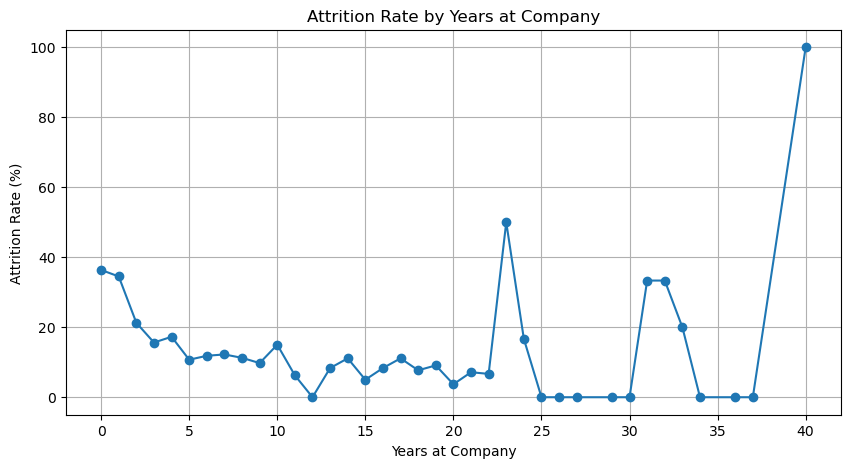

In [103]:
# 5. Attrition vs Years at Company #

years_attrition = (df.groupby("YearsAtCompany")["Attrition"].mean() * 100)
print(years_attrition.head(15))

plt.figure(figsize=(10,5))
years_attrition.plot(marker='o')
plt.title("Attrition Rate by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.grid(True)
plt.show()

In [36]:
#  business insights from your EDA #

print("""
 business insights from Exploitary Data Analysis

1. The Sales department has the highest attrition rate at 20.63%, followed by Human Resources of 19.05%. 
   The Research & Development department has the lowest attrition rate at 13.84%, indicating better employee retention in this department.

2. Among all job roles, Sales Representatives have the highest attrition rate of 39.76%, followed by Laboratory
   Technicians of 23.94% and Human Resources employees of 23.08%. In contrast, Research Directors of 2.50% and
   Managers of 4.90% have the lowest attrition rates, suggesting these roles are more stable.

3. The Monthly Income analysis shows that employees who stayed have a median monthly income of ₹5,204, while employees
   who left have a median monthly income of ₹3,202. This indicates that lower-paid employees are more likely to leave the
   company, although a few high-income employees also resigned, as shown by the outliers in the box plot.

4. Employees with a Work-Life Balance rating of 1 have the highest attrition rate at 31.25%, which is almost double
   that of employees with ratings 2 of 16.86% and 3 of 14.22%. This suggests that poor work-life balance is strongly
   associated with employee attrition.

5. Attrition is highest during the first two years of employment, with 36.36% of employees leaving within the first 
   year and 34.50% leaving after one year. The attrition rate gradually decreases as tenure increases, indicating that
   employees who stay longer are more likely to remain with the company.
   """)


 business insights from Exploitary Data Analysis

1. The Sales department has the highest attrition rate at 20.63%, followed by Human Resources of 19.05%. 
   The Research & Development department has the lowest attrition rate at 13.84%, indicating better employee retention in this department.

2. Among all job roles, Sales Representatives have the highest attrition rate of 39.76%, followed by Laboratory
   Technicians of 23.94% and Human Resources employees of 23.08%. In contrast, Research Directors of 2.50% and
   Managers of 4.90% have the lowest attrition rates, suggesting these roles are more stable.

3. The Monthly Income analysis shows that employees who stayed have a median monthly income of ₹5,204, while employees
   who left have a median monthly income of ₹3,202. This indicates that lower-paid employees are more likely to leave the
   company, although a few high-income employees also resigned, as shown by the outliers in the box plot.

4. Employees with a Work-Life Balance

In [37]:
### Task 4 – Model Building & Comparison ###

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.20,random_state=42,stratify=y) 
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

# models
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)  # traing model
    y_pred = model.predict(X_test) # predicting the model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })  # Storing metrics
    print("="*60)
    print(name)
    print("="*60)
    print(classification_report(y_test, y_pred))

#comparing the results
comparison = pd.DataFrame(results)
comparison = comparison.round(4)
comparison

Training Set: (1176, 45)
Testing Set: (294, 45)
Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73     

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.7483,0.3412,0.6170,0.4394
1,Random Forest,0.8401,0.5000,0.0638,0.1132
2,Gradient Boosting,0.8503,0.5882,0.2128,0.3125


In [38]:
print("""

## Observation from model comparision

-> Logistic Regression achieved the highest recall because of the class_weight="balanced" parameter, making it effective
   at identifying employees who are likely to leave.
-> Random Forest produced the highest overall accuracy but lower recall, indicating it missed more attrition cases.
-> Gradient Boosting provided a good balance between precision and recall.
-> Since employee attrition prediction focuses on identifying employees who may leave, Recall and F1-Score are more important than Accuracy alone.

""")



## Observation from model comparision

-> Logistic Regression achieved the highest recall because of the class_weight="balanced" parameter, making it effective
   at identifying employees who are likely to leave.
-> Random Forest produced the highest overall accuracy but lower recall, indicating it missed more attrition cases.
-> Gradient Boosting provided a good balance between precision and recall.
-> Since employee attrition prediction focuses on identifying employees who may leave, Recall and F1-Score are more important than Accuracy alone.




Logistic Regression
Precision : 0.3412
Recall    : 0.6170
F1-Score  : 0.4394
ROC-AUC   : 0.7986


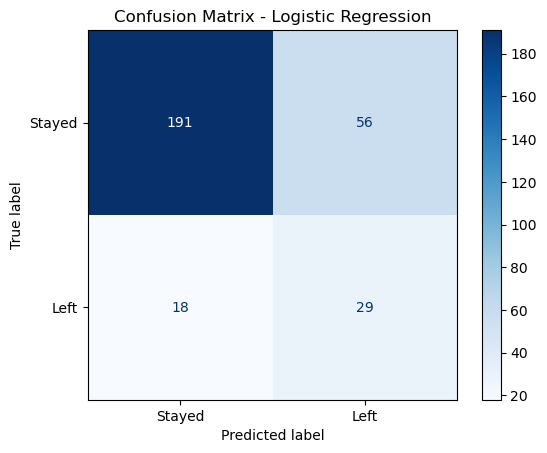

Random Forest
Precision : 0.5000
Recall    : 0.0638
F1-Score  : 0.1132
ROC-AUC   : 0.7752


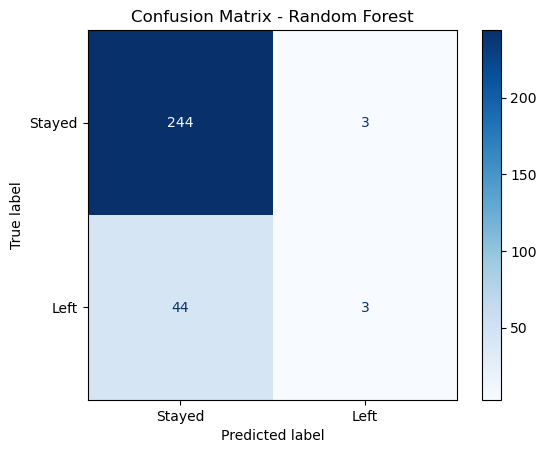

Gradient Boosting
Precision : 0.5882
Recall    : 0.2128
F1-Score  : 0.3125
ROC-AUC   : 0.7937


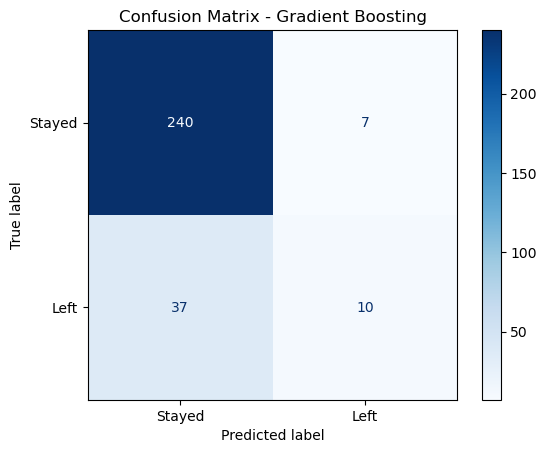

Best Model: Logistic Regression


In [107]:
### Task 5 — Model Evaluation ###

from sklearn.metrics import (precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
evaluation_results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # predicting probability of ROC

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    evaluation_results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    print("="*60)
    print(name)
    print("="*60)

    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    #confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Stayed", "Left"]).plot(cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

evaluation_df = pd.DataFrame(evaluation_results)  #evaluation results
evaluation_df = evaluation_df.round(4)
evaluation_df

#evaluting the best model
best_model_name = evaluation_df.sort_values( by="F1-Score",ascending=False).iloc[0]["Model"]
print("Best Model:", best_model_name)
best_model = models[best_model_name]


,Rank,Feature,Coefficient,Importance,Interpretation
35,1,JobRole_Laboratory Technician,0.797874,0.797874,Higher likelihood of attrition
44,2,OverTime_Yes,0.766412,0.766412,Higher likelihood of attrition
24,3,BusinessTravel_Travel_Frequently,0.719335,0.719335,Higher likelihood of attrition
8,4,JobLevel,0.659189,0.659189,Higher likelihood of attrition
17,5,TotalWorkingYears,-0.656931,0.656931,Lower likelihood of attrition
41,6,JobRole_Sales Representative,0.552515,0.552515,Higher likelihood of attrition
25,7,BusinessTravel_Travel_Rarely,0.511649,0.511649,Higher likelihood of attrition
28,8,EducationField_Life Sciences,-0.506505,0.506505,Lower likelihood of attrition
22,9,YearsSinceLastPromotion,0.500389,0.500389,Higher likelihood of attrition
27,10,Department_Sales,0.481690,0.481690,Higher likelihood of attrition


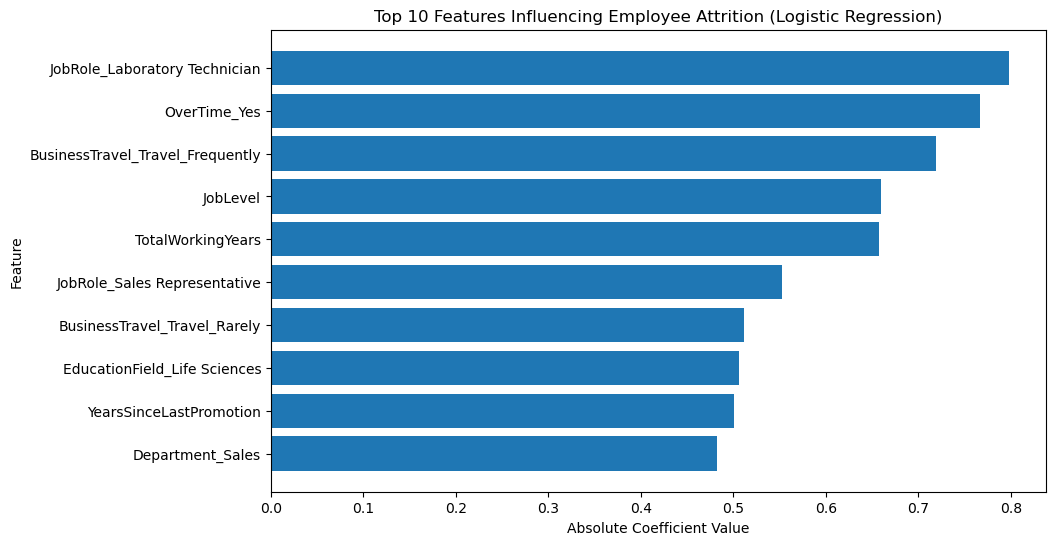

In [108]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({"Feature": X_train.columns,"Coefficient": best_model.coef_[0]})
feature_importance["Importance"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
feature_importance["Rank"] = range(1, len(feature_importance) + 1)
top10_features = feature_importance.head(10).copy()

top10_features["Interpretation"] = top10_features["Coefficient"].apply(
    lambda x: "Higher likelihood of attrition" if x > 0 else "Lower likelihood of attrition")

# Selecting columns
top10_features = top10_features[["Rank", "Feature", "Coefficient", "Importance", "Interpretation"]]
display(top10_features)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Employee Attrition (Logistic Regression)")
plt.show()

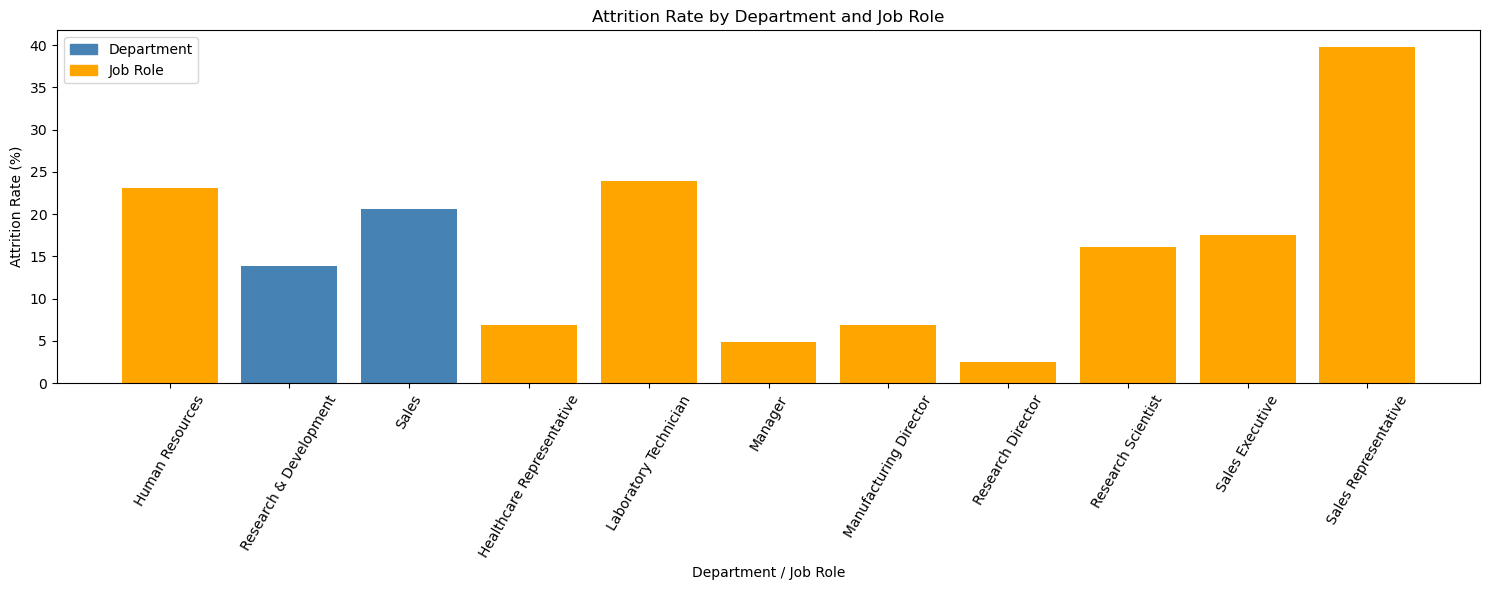

In [43]:
### Task 6 — Visualization ###

#Chart 1: Bar Chart – Attrition Rate by Department abd job role

dept = df.groupby("Department")["Attrition"].mean().mul(100)
job = df.groupby("JobRole")["Attrition"].mean().mul(100)
combined = pd.concat([dept, job])
colors = (["steelblue"] * len(dept) +["orange"] * len(job))

plt.figure(figsize=(15,6))
plt.bar(combined.index, combined.values, color=colors)
plt.title("Attrition Rate by Department and Job Role")
plt.xlabel("Department / Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=60)

plt.legend(
    handles=[
        plt.Rectangle((0,0),1,1,color="steelblue"),
        plt.Rectangle((0,0),1,1,color="orange")
    ],
    labels=["Department","Job Role"]
)

plt.tight_layout()
plt.show()

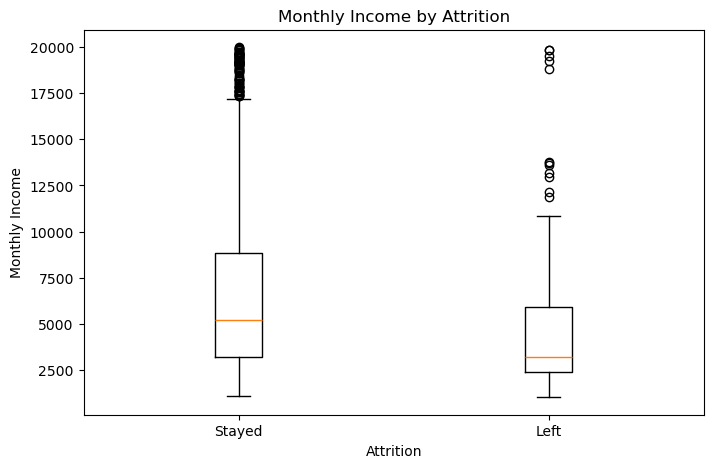

In [110]:
# Chart 2: Box Plot – Monthly Income #

plt.figure(figsize=(8,5))
plt.boxplot([df[df["Attrition"]==0]["MonthlyIncome"],df[df["Attrition"]==1]["MonthlyIncome"]],tick_labels=["Stayed","Left"])
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

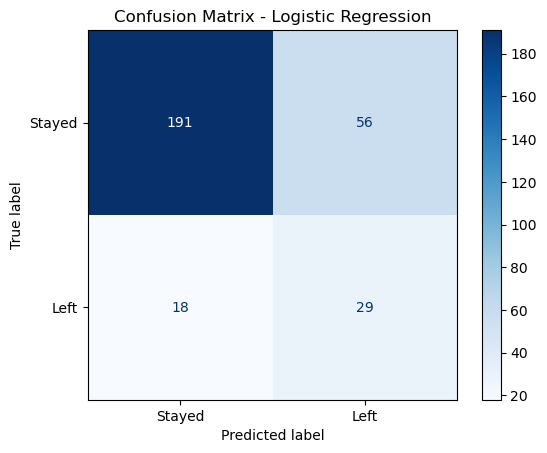

In [111]:
# Chart 3: Confusion Matrix Heatmap (Best Model) #

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Stayed","Left"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

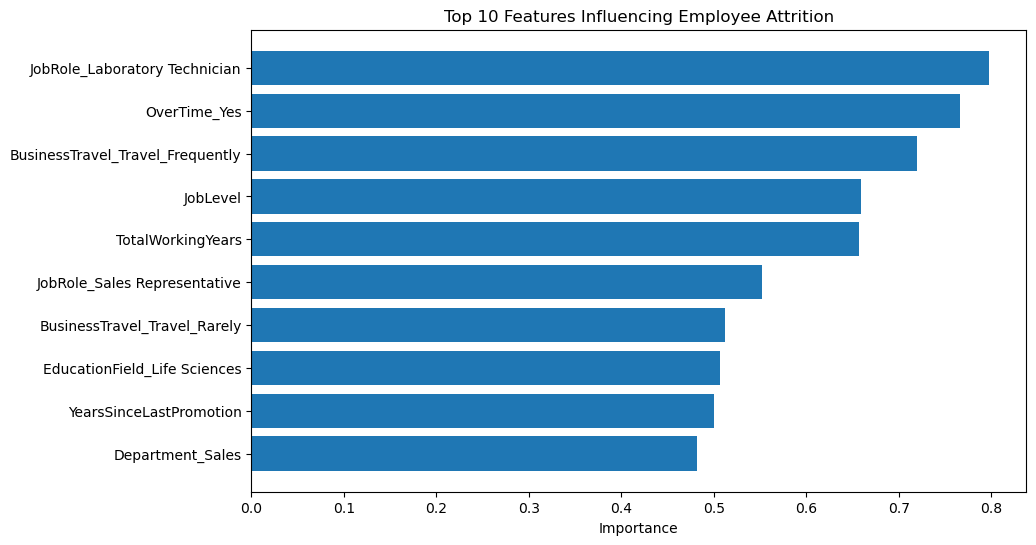

In [112]:
# Chart 4: Horizontal Bar Chart – Top 10 Feature Importance #

plt.figure(figsize=(10,6))
plt.barh(top10_features["Feature"],top10_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Features Influencing Employee Attrition")
plt.show()

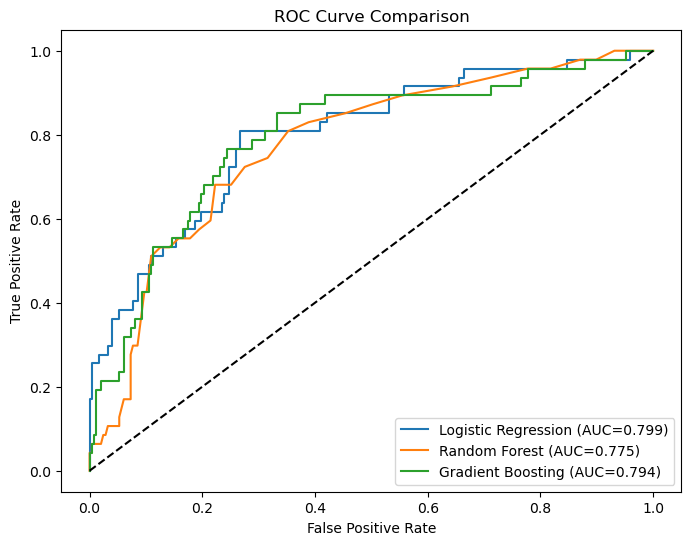

In [113]:
# Chart 5: ROC Curve Comparison #

from sklearn.metrics import roc_curve, roc_auc_score
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [115]:
### Task 7 — HR Insights & Business Recommendations ###

print("""

HR Insights & Business Recommendations


1. The three strongest predictors of employee attrition identified by the Logistic Regression model are:

    ->Job Role – Employees working as Laboratory Technicians have the highest likelihood of leaving.
    ->OverTime – Employees who frequently work overtime are much more likely to leave the organization.
    ->Business Travel – Employees who travel frequently for work have a higher risk of attrition.


2. HR should primarily focus on:
   ->The Sales Department, which has the highest department attrition rate of 20.63%.
   ->Sales Representatives of 39.76% attrition and Laboratory Technicians of 23.94% attrition,
     as these job roles experience the highest employee turnover.


3. No. Although employees with lower monthly income are more likely to leave, salary is not the only factor influencing attrition. 
   Factors such as overtime, frequent business travel, job role, years since last promotion, and total working experience have a 
   significant impact on employee turnover.

 HR Recommendations

1. Recommendation-1

-> Implement a targeted retention program for Sales Representatives,Laboratory Technicians, and employees who frequently work overtime. 
   This could include workload balancing, flexible work arrangements, career development plans, and regular one-on-one retention discussions.

2. Recommendation-2

-> Review promotion and career growth policies for employees who have not received a promotion for several years. Providing timely promotions,
   learning opportunities, and clear career progression paths can improve employee satisfaction and reduce attrition.

 Model Limitation

-> The model predicts employee attrition based only on the available HR dataset. It does not consider important external factors 
   such as employee motivation, manager relationships, workplace culture, personal circumstances, job satisfaction changes over time,
   or economic conditions. Therefore, HR should use the model as a decision-support tool rather than the sole basis for making employee 
   retention decisions.

   """)




HR Insights & Business Recommendations


1. The three strongest predictors of employee attrition identified by the Logistic Regression model are:

    ->Job Role – Employees working as Laboratory Technicians have the highest likelihood of leaving.
    ->OverTime – Employees who frequently work overtime are much more likely to leave the organization.
    ->Business Travel – Employees who travel frequently for work have a higher risk of attrition.


2. HR should primarily focus on:
   ->The Sales Department, which has the highest department attrition rate of 20.63%.
   ->Sales Representatives of 39.76% attrition and Laboratory Technicians of 23.94% attrition,
     as these job roles experience the highest employee turnover.


3. No. Although employees with lower monthly income are more likely to leave, salary is not the only factor influencing attrition. 
   Factors such as overtime, frequent business travel, job role, years since last promotion, and total working experience have a 
  